In [1]:
from jax import random, numpy as jnp
from lqg import xcorr
from lqg.belief import kf
import matplotlib.pyplot as plt
import jax

jax.config.update("jax_enable_x64", True)

from cppp.models.multisensory import BoundedActorPointMassDynamics, BoundedActor



/scratch/ds2181/cpp-proprioception/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


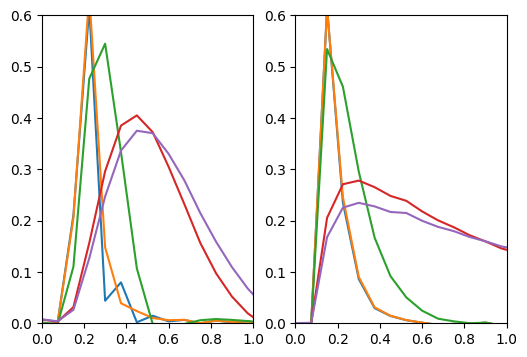

In [2]:
dt = 0.075

f, ax = plt.subplots(1, 2, figsize=(6, 4))
for c in [1e-6, 1e-4, 1e-2, 1., 2.]:
    for i, model in enumerate([BoundedActorPointMassDynamics(action_cost=c , sigmas=[1.], action_variability=0.1, delays=[1], dt=dt), 
                  BoundedActor(action_cost=c, sigmas=[1.], action_variability=0.1, delays=[1], dt=dt)]):
        key = random.PRNGKey(0)
        
        x = model.simulate(key, n=100)
        print(model)
        vels = jnp.diff(x, axis=-2)
        lags, correls = xcorr(vels[..., 1], vels[..., 0], maxlags=25)

        ax[i].plot(lags[25:] * dt, correls.mean(axis=0)[25:])
        ax[i].set_xlim(0, 1.)
        ax[i].set_ylim(0., 0.6)

In [3]:
model.actor.B[0].T @ model.actor.B[0]

Array([[0.005625]], dtype=float64)

In [4]:
1 / dt

13.333333333333334

In [4]:
dt

0.075